# Prueba Tecnica - Practicante Data Engineer
## Pipeline ETL Lakehouse: RAW -> STAGE -> ANALYTICS

## 0. Configuracion inicial

In [28]:

import pandas as pd
import numpy as np
import sqlite3
import hashlib
from datetime import datetime
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [29]:
from google.colab import drive
drive.mount('/content/drive')

# Ruta donde estan los 3 CSV (AJUSTAR segun donde los compartan)
RUTA_DATOS = '/content/drive/MyDrive/PruebaTecnica/'

DB_PATH = 'lakehouse.db'
conn = sqlite3.connect(DB_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Ingesta de datos (capa RAW)

### 1.1 Carga de archivos CSV

In [3]:
# RAW = copia fiel de la fuente, sin transformar nada. Por eso cargo todo
# como texto (dtype=str), para que pandas no adivine tipos sobre datos sucios.
df_raw_customers = pd.read_csv(RUTA_DATOS + "customers.csv", dtype=str)
df_raw_products = pd.read_csv(RUTA_DATOS + "products.csv", dtype=str)
df_raw_orders = pd.read_csv(RUTA_DATOS + "orders.csv", dtype=str)

df_raw_customers.to_sql("raw_customers", conn, if_exists="replace", index=False)
df_raw_products.to_sql("raw_products", conn, if_exists="replace", index=False)
df_raw_orders.to_sql("raw_orders", conn, if_exists="replace", index=False)

520

### 1.2 Resumen de la ingesta

In [4]:
for nombre, df in [("customers", df_raw_customers), ("products", df_raw_products), ("orders", df_raw_orders)]:
    print(f"--- {nombre} ---")
    print("Filas:", len(df))
    print("Columnas:", list(df.columns))
    print("Nulos por columna:")
    print(df.isna().sum())
    print("Duplicados exactos:", df.duplicated().sum())
    print()

--- customers ---
Filas: 109
Columnas: ['customer_id', 'first_name', 'last_name', 'email', 'phone', 'city', 'country', 'age', 'registration_date', 'loyalty_tier']
Nulos por columna:
customer_id           3
first_name            6
last_name             3
email                 3
phone                 8
city                  3
country               3
age                  31
registration_date     3
loyalty_tier         13
dtype: int64
Duplicados exactos: 8

--- products ---
Filas: 47
Columnas: ['product_id', 'product_name', 'category', 'price_usd', 'cost_usd', 'stock_units', 'supplier', 'active']
Nulos por columna:
product_id       0
product_name     0
category         0
price_usd        0
cost_usd         3
stock_units     24
supplier        12
active           0
dtype: int64
Duplicados exactos: 0

--- orders ---
Filas: 520
Columnas: ['order_id', 'customer_id', 'product_id', 'quantity', 'unit_price_usd', 'total_amount_usd', 'order_date', 'ship_date', 'status', 'payment_method', 'discount_

## 2. Identificacion de problemas (EDA inicial, antes de limpiar)

### 2.1 Analisis univariado - variables categoricas

In [5]:
print(df_raw_customers["country"].value_counts(dropna=False))
print()
print(df_raw_customers["loyalty_tier"].value_counts(dropna=False))

country
COLOMBIA    28
Col.        21
colombia    21
CO          19
Colombia    17
NaN          3
Name: count, dtype: int64

loyalty_tier
Gold      27
bronze    21
GOLD      20
Silver    15
NaN       13
Bronze    13
Name: count, dtype: int64


In [6]:
print(df_raw_products["supplier"].value_counts(dropna=False))
print()
print(df_raw_products["active"].value_counts(dropna=False))

supplier
proveedor_a    12
NaN            12
Proveedor C    10
ProveedorA      8
ProveedorB      5
Name: count, dtype: int64

active
false    12
1         9
True      8
FALSE     6
true      6
0         6
Name: count, dtype: int64


In [7]:
print(df_raw_orders["status"].value_counts(dropna=False))
print()
print(df_raw_orders["payment_method"].value_counts(dropna=False))

status
cancelled    73
COMPLETED    69
returned     69
Pending      68
Cancelled    66
pending      59
Completed    57
completed    54
NaN           5
Name: count, dtype: int64

payment_method
PayPal         98
paypal         97
cash           92
credit_card    80
Credit Card    78
debit_card     70
NaN             5
Name: count, dtype: int64


### 2.2 Analisis univariado - variables numericas

In [8]:
pd.to_numeric(df_raw_customers["age"], errors="coerce").describe()

,age
count,78.000000
mean,65.051282
std,84.577314
min,-5.000000
25%,-5.000000
50%,25.500000
75%,200.000000
max,200.000000


In [9]:
pd.to_numeric(df_raw_products["price_usd"], errors="coerce").describe()

,price_usd
count,47.000000
mean,624.974681
std,557.788319
min,-1424.710000
25%,209.265000
50%,596.920000
75%,1056.470000
max,1497.200000


In [10]:
pd.to_numeric(df_raw_orders["total_amount_usd"], errors="coerce").describe()

,total_amount_usd
count,515.000000
mean,3777.743282
std,3504.820759
min,26.480000
25%,976.950000
50%,2602.240000
75%,5795.535000
max,14994.100000


## 3. Limpieza y transformacion (capa STAGE)

### 3.1 Limpieza de customers

In [11]:
df_customers = df_raw_customers.copy()

# Quito filas donde TODAS las columnas son nulas
df_customers = df_customers.dropna(how="all")

# Texto en mayusculas, columna por columna
df_customers["first_name"] = df_customers["first_name"].astype(str).str.strip().str.upper()
df_customers["last_name"] = df_customers["last_name"].astype(str).str.strip().str.upper()
df_customers["city"] = df_customers["city"].astype(str).str.strip().str.upper()
df_customers["loyalty_tier"] = df_customers["loyalty_tier"].astype(str).str.strip().str.upper()
df_customers["loyalty_tier"] = df_customers["loyalty_tier"].replace({"NAN": np.nan})

# customer_id como entero (Int64 soporta nulos, a diferencia del int normal)
df_customers["customer_id"] = pd.to_numeric(df_customers["customer_id"], errors="coerce").astype("Int64")

# age como numero, para poder validar el rango despues
df_customers["age"] = pd.to_numeric(df_customers["age"], errors="coerce")

# registration_date viene con 3 formatos de separador (-, /, .) en la misma
# columna; normalizo todo a guion antes de convertir a fecha
df_customers["registration_date"] = (
    df_customers["registration_date"].astype(str)
    .str.replace(".", "-", regex=False)
    .str.replace("/", "-", regex=False)
)
df_customers["registration_date"] = pd.to_datetime(df_customers["registration_date"], errors="coerce")

# Pais unico: el negocio confirma que todos los clientes son de Colombia
df_customers["country"] = "COLOMBIA"

# loyalty_tier invalido (no es SILVER/GOLD/BRONZE, incluye nulos) -> NO DETERMINADO
loyalty_validos = ["SILVER", "GOLD", "BRONZE"]
df_customers.loc[~df_customers["loyalty_tier"].isin(loyalty_validos), "loyalty_tier"] = "NO DETERMINADO"

# Edad imposible (negativa o mayor a 100) se marca como nula
edad_invalida = (df_customers["age"] < 0) | (df_customers["age"] > 100)
print(f"Edades invalidas encontradas: {edad_invalida.sum()}")
df_customers.loc[edad_invalida, "age"] = np.nan

# Duplicados de customer_id: me quedo con el de fecha de registro MAS ANTIGUA
df_customers = df_customers.sort_values("registration_date", na_position="last")
df_customers = df_customers.drop_duplicates(subset="customer_id", keep="first")

# Columna de auditoria
df_customers["updated_at"] = datetime.now().isoformat(timespec="seconds")

df_customers.to_sql("stg_customers", conn, if_exists="replace", index=False)
df_customers.head()

Edades invalidas encontradas: 49


,customer_id,first_name,last_name,email,phone,city,country,age,registration_date,loyalty_tier,updated_at
48,1008,MARÍA,VARGAS,maria.vargas9@gmail.com,+57 3249877065,BOGOTA,COLOMBIA,NaN,2023-01-12,GOLD,2026-06-17T15:34:44
9,1015,MATEO,DÍAZ,mateo.diaz32@gmail.com,+57 3128434500,MEDELLIN,COLOMBIA,NaN,2023-01-16,GOLD,2026-06-17T15:34:44
51,1039,LAURA,CASTRO,laura.castro9@gmail.com,+57 3111520596,BARRANQUILLA,COLOMBIA,NaN,2023-01-21,SILVER,2026-06-17T15:34:44
102,1071,MATEO,VARGAS,mateo.vargas49@gmail.com,+57 3212817745,BARRANQUILLA,COLOMBIA,NaN,2023-01-26,GOLD,2026-06-17T15:34:44
97,1037,JUAN,MORALES,juan.morales22@gmail.com,+57 3149961107,BOGOTA,COLOMBIA,NaN,2023-01-28,BRONZE,2026-06-17T15:34:44


### 3.2 Limpieza de products

In [12]:
df_products = df_raw_products.copy()

df_products = df_products.dropna(how="all")

# product_id duplicado: elimino 1, me quedo con el primero
df_products = df_products.drop_duplicates(subset="product_id", keep="first")

# Texto en mayusculas
df_products["product_name"] = df_products["product_name"].astype(str).str.strip().str.upper()
df_products["category"] = df_products["category"].astype(str).str.strip().str.upper()
df_products["supplier"] = df_products["supplier"].astype(str).str.strip().str.upper()

# supplier: cambio guion bajo por espacio, y aseguro un espacio entre
# PROVEEDOR y la letra (PROVEEDORA -> PROVEEDOR A, PROVEEDOR_A -> PROVEEDOR A)
df_products["supplier"] = df_products["supplier"].str.replace("_", " ", regex=False)
df_products["supplier"] = df_products["supplier"].str.replace(r"PROVEEDOR\s*", "PROVEEDOR ", regex=True)

# supplier que no tenga el formato "PROVEEDOR X" (incluye nulos) -> NO DETERMINADO
formato_valido = df_products["supplier"].str.match(r"^PROVEEDOR [A-Z]$", na=False)
print(f"supplier invalidos -> NO DETERMINADO: {(~formato_valido).sum()}")
df_products.loc[~formato_valido, "supplier"] = "NO DETERMINADO"

# active viene como texto/numero mixto (true, FALSE, 1, 0), lo paso a booleano real
mapa_booleano = {"true": True, "false": False, "1": True, "0": False}
df_products["active"] = df_products["active"].astype(str).str.strip().str.lower().map(mapa_booleano)
# si quedo algo sin reconocer, asumo inactivo por precaucion (active debe tener solo 2 valores)
df_products["active"] = df_products["active"].fillna(False)

# product_id como entero
df_products["product_id"] = pd.to_numeric(df_products["product_id"], errors="coerce").astype("Int64")

# Montos y stock como numero
df_products["price_usd"] = pd.to_numeric(df_products["price_usd"], errors="coerce")
df_products["cost_usd"] = pd.to_numeric(df_products["cost_usd"], errors="coerce")
df_products["stock_units"] = pd.to_numeric(df_products["stock_units"], errors="coerce")

# Valores negativos o nulos en estas columnas se reemplazan por 0
for columna in ["price_usd", "cost_usd", "stock_units"]:
    invalidos = (df_products[columna] < 0) | df_products[columna].isna()
    print(f"{columna}: {invalidos.sum()} valores invalidos reemplazados por 0")
    df_products.loc[invalidos, columna] = 0

df_products["updated_at"] = datetime.now().isoformat(timespec="seconds")

df_products.to_sql("stg_products", conn, if_exists="replace", index=False)
df_products.head()

supplier invalidos -> NO DETERMINADO: 10
price_usd: 1 valores invalidos reemplazados por 0
cost_usd: 2 valores invalidos reemplazados por 0
stock_units: 23 valores invalidos reemplazados por 0


,product_id,product_name,category,price_usd,cost_usd,stock_units,supplier,active,updated_at
0,2043,JUEGO DE MESA,TOYS,841.55,579.97,0.0,PROVEEDOR C,False,2026-06-17T15:34:44
1,2038,BASE MAQUILLAJE,BEAUTY,264.06,144.68,348.0,PROVEEDOR A,False,2026-06-17T15:34:44
2,2014,SUDADERA HOODIE,CLOTHING,192.73,92.67,0.0,PROVEEDOR C,False,2026-06-17T15:34:44
3,2015,PANTALON CARGO,CLOTHING,106.76,70.09,474.0,PROVEEDOR C,False,2026-06-17T15:34:44
4,2013,ZAPATOS RUNNING,CLOTHING,586.61,237.41,0.0,PROVEEDOR A,True,2026-06-17T15:34:44


### 3.3 Limpieza de orders

In [13]:
df_orders = df_raw_orders.copy()

df_orders = df_orders.dropna(how="all")

# order_id duplicado: elimino 1, me quedo con el primero
df_orders = df_orders.drop_duplicates(subset="order_id", keep="first")

# payment_method: cambio guion bajo por espacio antes de mayusculizar
# (debit_card -> debit card, para que coincida con "Credit Card")
df_orders["payment_method"] = df_orders["payment_method"].astype(str).str.replace("_", " ", regex=False)

# Texto en mayusculas
df_orders["status"] = df_orders["status"].astype(str).str.strip().str.upper()
df_orders["payment_method"] = df_orders["payment_method"].str.strip().str.upper()

# Identificadores como entero
df_orders["order_id"] = pd.to_numeric(df_orders["order_id"], errors="coerce").astype("Int64")
df_orders["customer_id"] = pd.to_numeric(df_orders["customer_id"], errors="coerce").astype("Int64")
df_orders["product_id"] = pd.to_numeric(df_orders["product_id"], errors="coerce").astype("Int64")
df_orders["credit_card_last4"] = pd.to_numeric(df_orders["credit_card_last4"], errors="coerce").astype("Int64")

# Fechas: normalizo separadores y convierto
df_orders["order_date"] = (
    df_orders["order_date"].astype(str)
    .str.replace(".", "-", regex=False)
    .str.replace("/", "-", regex=False)
)
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"], errors="coerce")

df_orders["ship_date"] = (
    df_orders["ship_date"].astype(str)
    .str.replace(".", "-", regex=False)
    .str.replace("/", "-", regex=False)
)
df_orders["ship_date"] = pd.to_datetime(df_orders["ship_date"], errors="coerce")

# Montos, cantidad y descuento como numero
df_orders["unit_price_usd"] = pd.to_numeric(df_orders["unit_price_usd"], errors="coerce")
df_orders["total_amount_usd"] = pd.to_numeric(df_orders["total_amount_usd"], errors="coerce")
df_orders["quantity"] = pd.to_numeric(df_orders["quantity"], errors="coerce")
df_orders["discount_pct"] = pd.to_numeric(df_orders["discount_pct"], errors="coerce")

# order_id no puede ser nulo: sin id no se puede identificar el pedido
antes = len(df_orders)
df_orders = df_orders.dropna(subset=["order_id"])
print(f"Filas eliminadas por order_id nulo: {antes - len(df_orders)}")

# status y payment_method invalidos (incluye nulos) -> NO DETERMINADO
status_validos = ["COMPLETED", "PENDING", "CANCELLED", "RETURNED"]
pago_validos = ["PAYPAL", "CASH", "CREDIT CARD", "DEBIT CARD"]
df_orders.loc[~df_orders["status"].isin(status_validos), "status"] = "NO DETERMINADO"
df_orders.loc[~df_orders["payment_method"].isin(pago_validos), "payment_method"] = "NO DETERMINADO"

# Precio/total negativo y descuento fuera de 0-100% se marcan como nulo
df_orders.loc[df_orders["total_amount_usd"] < 0, "total_amount_usd"] = np.nan
df_orders.loc[df_orders["unit_price_usd"] < 0, "unit_price_usd"] = np.nan
descuento_invalido = (df_orders["discount_pct"] < 0) | (df_orders["discount_pct"] > 100)
df_orders.loc[descuento_invalido, "discount_pct"] = np.nan

# quantity invalido (<=0 o nulo) NO se descarta: se recalcula con
# total_amount_usd / unit_price_usd cuando ambos son validos
quantity_invalida = (df_orders["quantity"] <= 0) | df_orders["quantity"].isna()
puede_recalcular = (
    quantity_invalida
    & df_orders["unit_price_usd"].notna()
    & (df_orders["unit_price_usd"] != 0)
    & df_orders["total_amount_usd"].notna()
)
df_orders.loc[puede_recalcular, "quantity"] = (
    df_orders.loc[puede_recalcular, "total_amount_usd"] / df_orders.loc[puede_recalcular, "unit_price_usd"]
).round()
print(f"quantity recalculada en {puede_recalcular.sum()} filas")

# ship_date anterior al order_date es imposible (no se puede enviar antes
# de pedir), se marca como nulo. NOTA: la indicacion original decia "mayor",
# pero eso anularia el ship_date en casi todos los pedidos validos (lo normal
# es que se envie despues de pedir); se interpreta como "menor".
ship_invalido = df_orders["ship_date"] < df_orders["order_date"]
df_orders.loc[ship_invalido, "ship_date"] = pd.NaT
print(f"ship_date anulado en {ship_invalido.sum()} filas")

df_orders["updated_at"] = datetime.now().isoformat(timespec="seconds")

df_orders.to_sql("stg_orders", conn, if_exists="replace", index=False)
df_orders.head()

Filas eliminadas por order_id nulo: 0
quantity recalculada en 50 filas
ship_date anulado en 30 filas


,order_id,customer_id,product_id,quantity,unit_price_usd,total_amount_usd,order_date,ship_date,status,payment_method,discount_pct,credit_card_last4,updated_at
0,3149,1064,2018,9,1385.04,12465.36,2023-11-15,2023-11-20,COMPLETED,PAYPAL,5.0,8454,2026-06-17T15:34:44
1,3286,1048,2035,9,85.43,768.87,2023-09-15,2023-09-28,PENDING,CASH,NaN,7025,2026-06-17T15:34:44
2,3451,1046,2004,3,52.98,158.94,2023-03-03,2023-03-17,CANCELLED,CREDIT CARD,10.0,4602,2026-06-17T15:34:44
3,3300,1024,2019,4,480.09,1920.36,2024-04-06,2024-04-11,CANCELLED,DEBIT CARD,15.0,3762,2026-06-17T15:34:44
4,3355,1014,2006,5,487.29,2436.45,2023-11-26,2023-12-07,COMPLETED,CREDIT CARD,0.0,4310,2026-06-17T15:34:44


### 3.4 Verificacion de calidad post-limpieza

In [14]:
for nombre, df in [("stg_customers", df_customers), ("stg_products", df_products), ("stg_orders", df_orders)]:
    print(f"--- {nombre} ---")
    print(df.dtypes)
    print(f"Filas totalmente nulas restantes: {df.isna().all(axis=1).sum()}")
    print()

--- stg_customers ---
customer_id                   Int64
first_name                   object
last_name                    object
email                        object
phone                        object
city                         object
country                      object
age                         float64
registration_date    datetime64[ns]
loyalty_tier                 object
updated_at                   object
dtype: object
Filas totalmente nulas restantes: 0

--- stg_products ---
product_id        Int64
product_name     object
category         object
price_usd       float64
cost_usd        float64
stock_units     float64
supplier         object
active             bool
updated_at       object
dtype: object
Filas totalmente nulas restantes: 0

--- stg_orders ---
order_id                      Int64
customer_id                   Int64
product_id                    Int64
quantity                      int64
unit_price_usd              float64
total_amount_usd            float64
order_da

## 4. Modelado de datos (capa ANALYTICS)

### 4.1 DIM_CLIENTE

In [15]:
# DIM = atributos descriptivos del cliente (quien es), 1 fila por cliente
dim_cliente = df_customers.copy()
dim_cliente["nombre_completo"] = (
    dim_cliente["first_name"].fillna("") + " " + dim_cliente["last_name"].fillna("")
).str.strip()

dim_cliente.to_sql("DIM_CLIENTE", conn, if_exists="replace", index=False)
print(f"DIM_CLIENTE: {len(dim_cliente)} filas")
dim_cliente.head()

DIM_CLIENTE: 100 filas


,customer_id,first_name,last_name,email,phone,city,country,age,registration_date,loyalty_tier,updated_at,nombre_completo
48,1008,MARÍA,VARGAS,maria.vargas9@gmail.com,+57 3249877065,BOGOTA,COLOMBIA,NaN,2023-01-12,GOLD,2026-06-17T15:34:44,MARÍA VARGAS
9,1015,MATEO,DÍAZ,mateo.diaz32@gmail.com,+57 3128434500,MEDELLIN,COLOMBIA,NaN,2023-01-16,GOLD,2026-06-17T15:34:44,MATEO DÍAZ
51,1039,LAURA,CASTRO,laura.castro9@gmail.com,+57 3111520596,BARRANQUILLA,COLOMBIA,NaN,2023-01-21,SILVER,2026-06-17T15:34:44,LAURA CASTRO
102,1071,MATEO,VARGAS,mateo.vargas49@gmail.com,+57 3212817745,BARRANQUILLA,COLOMBIA,NaN,2023-01-26,GOLD,2026-06-17T15:34:44,MATEO VARGAS
97,1037,JUAN,MORALES,juan.morales22@gmail.com,+57 3149961107,BOGOTA,COLOMBIA,NaN,2023-01-28,BRONZE,2026-06-17T15:34:44,JUAN MORALES


### 4.2 DIM_PRODUCTO

In [16]:
# DIM = atributos descriptivos del producto (que es), 1 fila por producto
dim_producto = df_products.copy()

dim_producto.to_sql("DIM_PRODUCTO", conn, if_exists="replace", index=False)
print(f"DIM_PRODUCTO: {len(dim_producto)} filas")
dim_producto.head()

DIM_PRODUCTO: 43 filas


,product_id,product_name,category,price_usd,cost_usd,stock_units,supplier,active,updated_at
0,2043,JUEGO DE MESA,TOYS,841.55,579.97,0.0,PROVEEDOR C,False,2026-06-17T15:34:44
1,2038,BASE MAQUILLAJE,BEAUTY,264.06,144.68,348.0,PROVEEDOR A,False,2026-06-17T15:34:44
2,2014,SUDADERA HOODIE,CLOTHING,192.73,92.67,0.0,PROVEEDOR C,False,2026-06-17T15:34:44
3,2015,PANTALON CARGO,CLOTHING,106.76,70.09,474.0,PROVEEDOR C,False,2026-06-17T15:34:44
4,2013,ZAPATOS RUNNING,CLOTHING,586.61,237.41,0.0,PROVEEDOR A,True,2026-06-17T15:34:44


### 4.3 FACT_VENTAS

In [17]:
# FACT = el hecho de negocio en si (una venta), a nivel de pedido individual,
# con llaves foraneas a DIM_CLIENTE y DIM_PRODUCTO. Reemplaza a los antiguos
# FACT_CLIENTE / FACT_PRODUCTO: ahora hay un unico fact table al grano de
# "venta", y cualquier metrica por cliente o por producto se calcula
# agregando esta tabla, no se pre-calcula en tablas separadas.

# Integridad referencial: los pedidos deben referenciar clientes y productos
# que realmente existen en las dimensiones; si no, se descartan
clientes_validos = set(dim_cliente["customer_id"])
productos_validos = set(dim_producto["product_id"])
fk_validas = df_orders["customer_id"].isin(clientes_validos) & df_orders["product_id"].isin(productos_validos)
print(f"Pedidos descartados por cliente/producto inexistente: {(~fk_validas).sum()}")

fact_ventas = df_orders[fk_validas].copy()

# Metrica derivada: dias que tardo el envio
fact_ventas["dias_envio"] = (fact_ventas["ship_date"] - fact_ventas["order_date"]).dt.days

fact_ventas.to_sql("FACT_VENTAS", conn, if_exists="replace", index=False)
print(f"FACT_VENTAS: {len(fact_ventas)} filas")
fact_ventas.head()

Pedidos descartados por cliente/producto inexistente: 27
FACT_VENTAS: 473 filas


,order_id,customer_id,product_id,quantity,unit_price_usd,total_amount_usd,order_date,ship_date,status,payment_method,discount_pct,credit_card_last4,updated_at,dias_envio
0,3149,1064,2018,9,1385.04,12465.36,2023-11-15,2023-11-20,COMPLETED,PAYPAL,5.0,8454,2026-06-17T15:34:44,5.0
1,3286,1048,2035,9,85.43,768.87,2023-09-15,2023-09-28,PENDING,CASH,NaN,7025,2026-06-17T15:34:44,13.0
2,3451,1046,2004,3,52.98,158.94,2023-03-03,2023-03-17,CANCELLED,CREDIT CARD,10.0,4602,2026-06-17T15:34:44,14.0
3,3300,1024,2019,4,480.09,1920.36,2024-04-06,2024-04-11,CANCELLED,DEBIT CARD,15.0,3762,2026-06-17T15:34:44,5.0
4,3355,1014,2006,5,487.29,2436.45,2023-11-26,2023-12-07,COMPLETED,CREDIT CARD,0.0,4310,2026-06-17T15:34:44,11.0


## 5. Reporte - Visualizaciones (analisis bivariado: cruces entre tablas)

### 5.1 Pregunta 1: Cuales son los 5 productos mas vendidos por ingresos

In [18]:
ingresos_por_producto = fact_ventas.groupby("product_id")["total_amount_usd"].sum().reset_index()
ingresos_por_producto = ingresos_por_producto.merge(
    dim_producto[["product_id", "product_name"]], on="product_id", how="left"
)
top5_productos = ingresos_por_producto.sort_values("total_amount_usd", ascending=False).head(5)
top5_productos[["product_name", "total_amount_usd"]]

,product_name,total_amount_usd
17,SARTEN ANTIADHERENTE,102586.92
35,SHAMPOO NATURAL,81622.77
22,PESAS AJUSTABLES,79757.86
37,BASE MAQUILLAJE,69972.65
18,JUEGO DE OLLAS,68604.94


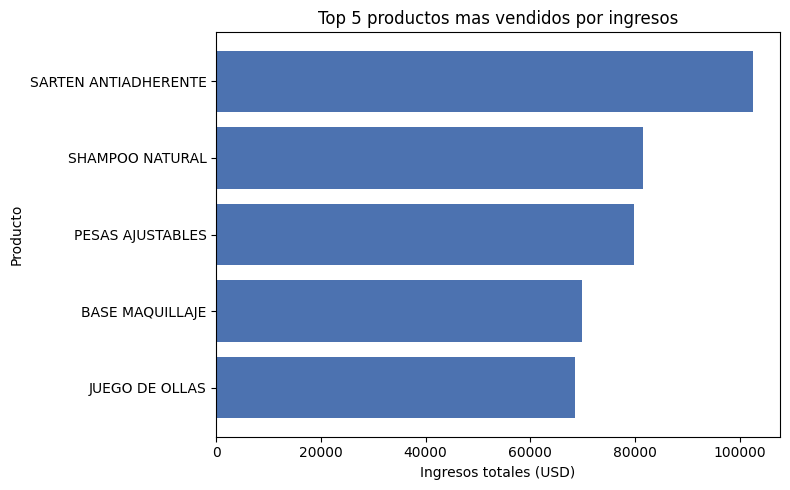

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top5_productos["product_name"], top5_productos["total_amount_usd"], color="#4C72B0")
ax.set_title("Top 5 productos mas vendidos por ingresos")
ax.set_xlabel("Ingresos totales (USD)")
ax.set_ylabel("Producto")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 5.2 Pregunta 2: Como evolucionaron las ventas mes a mes

In [20]:
ventas_mensuales = fact_ventas.copy()
ventas_mensuales["periodo"] = ventas_mensuales["order_date"].dt.to_period("M").astype(str)
ventas_mensuales = ventas_mensuales.groupby("periodo")["total_amount_usd"].sum().reset_index()
ventas_mensuales

,periodo,total_amount_usd
0,2023-01,77667.27
1,2023-02,58801.94
2,2023-03,103966.08
3,2023-04,61816.30
4,2023-05,71262.17
5,2023-06,219715.43
6,2023-07,104897.99
7,2023-08,124187.13
8,2023-09,65154.73
9,2023-10,72068.26


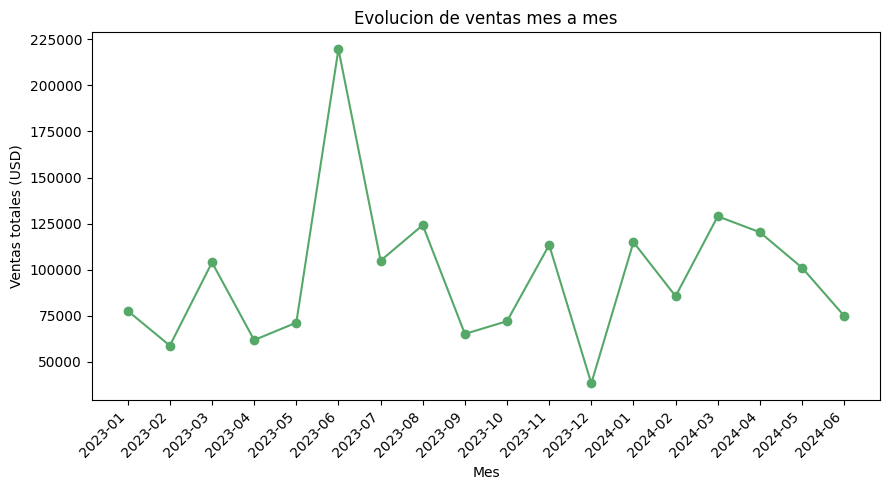

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ventas_mensuales["periodo"], ventas_mensuales["total_amount_usd"], marker="o", color="#55A868")
ax.set_title("Evolucion de ventas mes a mes")
ax.set_xlabel("Mes")
ax.set_ylabel("Ventas totales (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 5.3 Pregunta 3: Cual es el ticket promedio por categoria de producto

In [22]:
ventas_con_categoria = fact_ventas.merge(dim_producto[["product_id", "category"]], on="product_id", how="left")
ticket_categoria = ventas_con_categoria.groupby("category")["total_amount_usd"].mean().sort_values(ascending=False)
ticket_categoria

,total_amount_usd
category,
BEAUTY,4369.374074
SPORTS,3890.542500
BOOKS,3716.631311
HOME & KITCHEN,3661.625909
ELECTRONICS,3592.833803
TOYS,3273.029474
CLOTHING,3215.778065


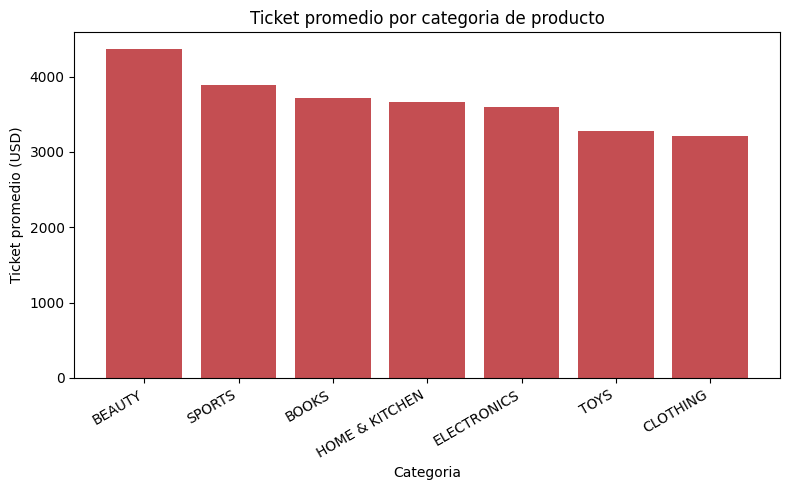

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(ticket_categoria.index, ticket_categoria.values, color="#C44E52")
ax.set_title("Ticket promedio por categoria de producto")
ax.set_xlabel("Categoria")
ax.set_ylabel("Ticket promedio (USD)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Examen SQL / Python

### 6.1 P1 - Top 3 clientes con mas pedidos en el ultimo trimestre disponible

In [24]:
fecha_max = fact_ventas["order_date"].max()
trimestre = (fecha_max.month - 1) // 3 + 1
inicio_trimestre = pd.Timestamp(year=fecha_max.year, month=(trimestre - 1) * 3 + 1, day=1)
fin_trimestre = inicio_trimestre + pd.DateOffset(months=3) - pd.DateOffset(days=1)

pedidos_trimestre = fact_ventas[
    (fact_ventas["order_date"] >= inicio_trimestre) & (fact_ventas["order_date"] <= fin_trimestre)
]

p1 = pedidos_trimestre.groupby("customer_id").size().reset_index(name="cantidad_pedidos")
p1 = p1.merge(dim_cliente[["customer_id", "nombre_completo"]], on="customer_id", how="left")
p1 = p1.sort_values("cantidad_pedidos", ascending=False).head(3)
p1 = p1[["customer_id", "nombre_completo", "cantidad_pedidos"]]
p1

,customer_id,nombre_completo,cantidad_pedidos
38,1077,VALENTINA MARTÍNEZ,3
28,1054,MATEO GARCÍA,3
24,1047,MIGUEL VARGAS,3


### 6.2 P2 - Revenue mensual por categoria de producto

In [25]:
df_p2 = fact_ventas.merge(dim_producto[["product_id", "category"]], on="product_id", how="left")
df_p2["anio"] = df_p2["order_date"].dt.year
df_p2["mes"] = df_p2["order_date"].dt.month

p2 = df_p2.groupby(["anio", "mes", "category"])["total_amount_usd"].sum().reset_index()
p2 = p2.rename(columns={"category": "categoria", "total_amount_usd": "revenue_total"})
p2 = p2.sort_values("revenue_total", ascending=False)
p2

,anio,mes,categoria,revenue_total
38,2023,6,SPORTS,62651.89
71,2023,11,HOME & KITCHEN,47417.69
37,2023,6,HOME & KITCHEN,44907.11
98,2024,3,HOME & KITCHEN,42671.56
33,2023,6,BEAUTY,36357.45
...,...,...,...,...
72,2023,11,SPORTS,1304.19
61,2023,10,BOOKS,1277.91
101,2024,4,BOOKS,863.23
79,2023,12,TOYS,838.12


### 6.3 P3 - Pedidos cuyo total_amount_usd supera 2 desviaciones estandar del promedio

In [26]:
media = fact_ventas["total_amount_usd"].mean()
desv_std = fact_ventas["total_amount_usd"].std()

p3 = fact_ventas[["order_id", "customer_id", "total_amount_usd"]].copy()
p3["z_score"] = (p3["total_amount_usd"] - media) / desv_std
p3 = p3[p3["z_score"].abs() > 2].sort_values("z_score", ascending=False)
p3

,order_id,customer_id,total_amount_usd,z_score
258,3226,1007,14994.10,3.251509
157,3496,1047,14664.70,3.156905
508,3057,1062,13821.80,2.914826
435,3291,1002,13783.20,2.903740
362,3411,1091,13553.70,2.837828
93,3385,1002,13454.40,2.809309
411,3258,1025,13398.00,2.793111
380,3035,1006,13337.10,2.775620
80,3004,1078,13287.50,2.761375
0,3149,1064,12465.36,2.525258


## 7. Seguridad de la informacion (PII)

In [27]:
# Columnas identificadas como PII en este dataset:
#   - email (DIM_CLIENTE): identificador directo de la persona -> se hashea
#   - phone (DIM_CLIENTE): identificador directo -> se enmascara
#   - credit_card_last4 (FACT_VENTAS): dato financiero sensible -> se enmascara

def hash_sha256(valor):
    if pd.isna(valor):
        return valor
    return hashlib.sha256(str(valor).strip().lower().encode("utf-8")).hexdigest()


def enmascarar(valor, n=4):
    if pd.isna(valor):
        return valor
    s = str(int(valor)) if isinstance(valor, float) else str(valor)
    if len(s) <= n:
        return "*" * len(s)
    return "*" * (len(s) - n) + s[-n:]


dim_cliente_seguro = dim_cliente.copy()
dim_cliente_seguro["email"] = dim_cliente_seguro["email"].apply(hash_sha256)
dim_cliente_seguro["phone"] = dim_cliente_seguro["phone"].apply(enmascarar)
dim_cliente_seguro.to_sql("DIM_CLIENTE_SEGURO", conn, if_exists="replace", index=False)

fact_ventas_seguro = fact_ventas.copy()
# credit_card_last4 ya viene reducido a 4 digitos en la fuente, asi que solo
# antepongo el prefijo de enmascarado para que se vea como ****1234
fact_ventas_seguro["credit_card_last4"] = fact_ventas_seguro["credit_card_last4"].apply(
    lambda v: f"****{int(v)}" if pd.notna(v) else v
)
fact_ventas_seguro.to_sql("FACT_VENTAS_SEGURO", conn, if_exists="replace", index=False)

dim_cliente_seguro[["customer_id", "email", "phone"]].head()

,customer_id,email,phone
48,1008,c233be304ee32329dabc613f269f20a8c5836383bfe688...,**********7065
9,1015,473fc3584e4c494d666027658e6a7e6f9a98e4d554944f...,**********4500
51,1039,0e4444bc5d3d78bcef8759cc8ae536ce99a606d1e8a6f9...,**********0596
102,1071,253703fd90d7dd7dd084ddf238c6245cd20781f6b6f929...,**********7745
97,1037,851ec8a8c86671c86e28ee93312ff162fa11881eb6c77e...,**********1107
